In [1]:
# ============================================================
# CELL 1: INSTALL & IMPORTS
# ============================================================
import subprocess
subprocess.run(['pip', 'install', 'shap', 'imbalanced-learn', '-q'])

import os, warnings, json, glob, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm import tqdm

warnings.filterwarnings('ignore')

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
    print('Changed to:', os.getcwd())

# Sklearn
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

# PyTorch (GPU check)
import torch

print('✓ All imports successful!')
print(f'TensorFlow : {tf.__version__}')
print(f'PyTorch    : {torch.__version__}')

Changed to: D:\Downloads\cyber-attack-detection

✓ All imports successful!
TensorFlow : 2.15.0
PyTorch    : 2.7.1+cu118


In [2]:
# ============================================================
# CELL 2: GPU SETUP
# ============================================================
print('='*60)
print('GPU CONFIGURATION')
print('='*60)

if torch.cuda.is_available():
    print(f'✓ GPU : {torch.cuda.get_device_name(0)}')
    print(f'  CUDA: {torch.version.cuda}')
    tf_gpus = tf.config.list_physical_devices('GPU')
    if tf_gpus:
        for gpu in tf_gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'  ✓ TF memory growth enabled')
else:
    print('⚠ No GPU — using CPU')

for d in ['models', 'results', 'plots', 'checkpoints']:
    os.makedirs(d, exist_ok=True)

TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f'\n✓ Session: {TIMESTAMP}')

GPU CONFIGURATION
✓ GPU : NVIDIA GeForce RTX 3050 6GB Laptop GPU
  CUDA: 11.8

✓ Session: 20260417_200142


In [3]:
# ============================================================
# CELL 3: FOCAL LOSS DEFINITION
# Novel contribution: applied to IALSTM for smart camera IDS
# ============================================================
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss — invented for object detection (Lin et al., 2017).
    Applied here to fix extreme class imbalance in IoT attack detection.
    
    gamma: focusing parameter — higher = more focus on hard misclassified samples
    alpha: class balancing weight
    
    Formula: FL(pt) = -alpha * (1-pt)^gamma * log(pt)
    vs CrossEntropy: CE(pt) = -log(pt)
    
    When pt → 1 (easy example): (1-pt)^gamma → 0 → loss nearly zero
    When pt → 0 (hard example): (1-pt)^gamma → 1 → same as CrossEntropy
    """
    def loss_fn(y_true, y_pred):
        # Clip predictions for numerical stability
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        # Cross-entropy component
        cross_entropy = -y_true * K.log(y_pred)
        # Focal weight: down-weights easy (well-classified Normal) examples
        focal_weight = alpha * K.pow(1.0 - y_pred, gamma)
        # Focal loss
        fl = focal_weight * cross_entropy
        return K.mean(K.sum(fl, axis=-1))
    loss_fn.__name__ = f'focal_loss_g{gamma}_a{alpha}'
    return loss_fn

print('✓ Focal Loss defined')
print('  gamma=2.0 : focuses on hard/rare attack classes')
print('  alpha=0.25: balances Normal vs attack classes')
print('\n  This is the KEY DIFFERENCE from the base paper (Hazarika et al., 2025)')
print('  Base paper: CrossEntropy + binary classification')
print('  Our work  : Focal Loss + 10-class classification')

✓ Focal Loss defined
  gamma=2.0 : focuses on hard/rare attack classes
  alpha=0.25: balances Normal vs attack classes

  This is the KEY DIFFERENCE from the base paper (Hazarika et al., 2025)
  Base paper: CrossEntropy + binary classification
  Our work  : Focal Loss + 10-class classification


In [4]:
# ============================================================
# CELL 4: CONFIGURATION
# ============================================================
CONFIG = {
    'preprocessing': {
        'sequence_length': 30,
        'max_sequences' : 120_000,
        'test_size'     : 0.20,
        'val_size'      : 0.125,
    },
    # Method-1: IALSTM (from base paper) + Focal Loss + Multiclass
    'ialstm': {
        # Teacher LSTM (large)
        'teacher_units'  : [128, 64],
        'teacher_dropout': 0.3,
        # Student LSTM (compressed — IALSTM idea)
        'student_units'  : [32, 16],
        'student_dropout': 0.2,
        # KD temperature
        'kd_temperature' : 4.0,
        'kd_alpha'       : 0.7,    # weight for KD loss vs CE loss
        # Focal loss params
        'focal_gamma'    : 2.0,
        'focal_alpha'    : 0.25,
        # Training
        'batch_size'     : 64,
        'epochs'         : 100,
        'learning_rate'  : 0.001,
    },
    # Method-2: CNN-BiLSTM-Attention + Focal Loss
    'cnn_bilstm': {
        'cnn_filters'       : [32, 64],
        'kernel_size'       : 3,
        'pool_size'         : 2,
        'cnn_dropout'       : 0.3,
        'lstm_units'        : [32, 16],
        'lstm_dropout'      : 0.3,
        'attention_heads'   : 2,
        'attention_key_dim' : 16,
        'dense_units'       : 64,
        'dense_dropout'     : 0.3,
        # Focal loss params
        'focal_gamma'       : 2.0,
        'focal_alpha'       : 0.25,
        # Training
        'batch_size'        : 64,
        'epochs'            : 100,
        'learning_rate'     : 0.001,
    }
}
print('✓ Configuration loaded')

✓ Configuration loaded


In [6]:
# ============================================================
# CELL 5: LOAD TON_IoT DATASET
# Same dataset as base paper (Hazarika et al., 2025)
# Download: https://research.unsw.edu.au/projects/toniot-datasets
# Use: Network dataset CSV files
# ============================================================
print('='*60)
print('LOADING TON_IoT DATASET')
print('='*60)

# Try loading TON_IoT network data
# File paths — adjust to your local paths
possible_paths = [
    'data/raw/TON_IoT_Network.csv',
    'data/raw/Train_Test_Network.csv',
    'data/raw/ton_iot_network.csv',
    'data/raw/Network_dataset.csv',
]

df = None
for path in possible_paths:
    if os.path.exists(path):
        print(f'✓ Loading: {path}')
        df = pd.read_csv(path, low_memory=False)
        break

# If multiple files, combine them
if df is None:
    files = glob.glob('data/raw/Train_Test_Network*.csv') + \
            glob.glob('data/raw/TON_IoT*.csv') + \
            glob.glob('data/raw/*ton*iot*.csv')
    if files:
        print(f'Found {len(files)} files, combining...')
        df = pd.concat(
            [pd.read_csv(f, low_memory=False) for f in files],
            ignore_index=True
        )
        print(f'✓ Combined: {df.shape}')

if df is None:
    raise FileNotFoundError(
        '❌ TON_IoT not found in data/raw/\n'
        'Download from: https://research.unsw.edu.au/projects/toniot-datasets\n'
        'Place CSV files in data/raw/'
    )

print(f'\n✓ Dataset shape: {df.shape}')
print(f'✓ Columns: {df.columns.tolist()}')
print(f'\nFirst few rows:')
print(df.head(3))

LOADING TON_IoT DATASET
✓ Loading: data/raw/Train_Test_Network.csv

✓ Dataset shape: (211043, 44)
✓ Columns: ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']

First few rows:
          src_ip  src_port         dst_ip  dst_port proto service    duration  \
0   192.168.1.37      4444  192.168.1.193     49178   tcp       -  290.371539   
1  192.168.1.193     49180   192.168.1.37      8080   tcp       -    0

In [7]:
# ============================================================
# CELL 6: EXPLORE & MAP LABELS
# TON_IoT has 'type' column with attack names
# ============================================================
print('='*60)
print('EXPLORING TON_IoT LABELS')
print('='*60)

# Find label column — TON_IoT uses 'type' or 'label'
label_col = None
for col in ['type', 'label', 'attack_type', 'attack_cat', 'Type', 'Label']:
    if col in df.columns:
        label_col = col
        break

if label_col is None:
    print('Columns:', df.columns.tolist())
    label_col = input('Enter label column name: ')

print(f'✓ Label column: "{label_col}"')
print(f'\nClass distribution:')
vc = df[label_col].value_counts()
print(vc)

# Standardize label names
df[label_col] = df[label_col].astype(str).str.strip().str.lower()

# TON_IoT attack types:
# normal, scanning, dos/ddos, ransomware, backdoor,
# injection, xss, password, mitm
ATTACK_MAP = {
    'normal'    : 'Normal',
    'scanning'  : 'Scanning',
    'dos'       : 'DoS_DDoS',
    'ddos'      : 'DoS_DDoS',
    'dos/ddos'  : 'DoS_DDoS',
    'ransomware': 'Ransomware',
    'backdoor'  : 'Backdoor',
    'injection' : 'Injection',
    'xss'       : 'XSS',
    'password'  : 'Password',
    'mitm'      : 'MITM',
}

df['attack_type'] = df[label_col].map(ATTACK_MAP)

# Handle unmapped labels
unmapped = df['attack_type'].isna().sum()
if unmapped > 0:
    print(f'\n⚠ {unmapped} unmapped labels:')
    print(df[df['attack_type'].isna()][label_col].value_counts())
    # Keep original name for unmapped
    df['attack_type'] = df['attack_type'].fillna(
        df[label_col].str.title()
    )

print(f'\n✓ Final class distribution:')
print(df['attack_type'].value_counts())

EXPLORING TON_IoT LABELS
✓ Label column: "type"

Class distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
ransomware    20000
scanning      20000
xss           20000
mitm           1043
Name: count, dtype: int64

✓ Final class distribution:
attack_type
Normal        50000
DoS_DDoS      40000
Backdoor      20000
Injection     20000
Password      20000
Ransomware    20000
Scanning      20000
XSS           20000
MITM           1043
Name: count, dtype: int64


In [8]:
# ============================================================
# CELL 7: PREPROCESSING
# ============================================================
print('='*60)
print('PREPROCESSING')
print('='*60)

# Drop duplicates & nulls
df = df.drop_duplicates()
df = df.dropna(subset=['attack_type'])
print(f'✓ After cleaning: {df.shape}')

# Numeric features only
numeric_df = df.select_dtypes(include=[np.number])
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)
numeric_df = numeric_df.fillna(numeric_df.median())

FEATURE_NAMES = numeric_df.columns.tolist()
print(f'✓ Numeric features: {len(FEATURE_NAMES)}')

# Label encode
label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(df['attack_type'])
NUM_CLASSES = len(label_encoder.classes_)
CLASS_NAMES = list(label_encoder.classes_)
print(f'\n✓ Classes ({NUM_CLASSES}): {CLASS_NAMES}')

# Normalize
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(numeric_df).astype(np.float32)
print(f'✓ Scaled shape: {X_scaled.shape}')

# -----------------------------------------------
# Create sequences for LSTM-based models
# -----------------------------------------------
SEQ_LEN  = CONFIG['preprocessing']['sequence_length']
MAX_SEQ  = CONFIG['preprocessing']['max_sequences']
n_pos    = len(X_scaled) - SEQ_LEN
step     = max(1, n_pos // MAX_SEQ)

print(f'\nCreating sequences (len={SEQ_LEN}, step={step})...')
X_seq, y_seq = [], []
for i in tqdm(range(0, n_pos, step), desc='Sequences'):
    X_seq.append(X_scaled[i:i+SEQ_LEN])
    y_seq.append(y_all[i+SEQ_LEN-1])
X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq)
print(f'✓ Sequences: {X_seq.shape} ({X_seq.nbytes/1e6:.1f} MB)')

# Train/Val/Test split (stratified)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_seq, y_seq,
    test_size=CONFIG['preprocessing']['test_size'],
    random_state=SEED, stratify=y_seq
)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_tr, y_tr,
    test_size=CONFIG['preprocessing']['val_size'],
    random_state=SEED, stratify=y_tr
)
print(f'✓ Train:{X_tr.shape} Val:{X_va.shape} Test:{X_te.shape}')

# One-hot for softmax models
y_tr_cat = keras.utils.to_categorical(y_tr, NUM_CLASSES)
y_va_cat = keras.utils.to_categorical(y_va, NUM_CLASSES)
y_te_cat = keras.utils.to_categorical(y_te, NUM_CLASSES)

# Class distribution info
print('\n✓ Test set class distribution:')
for i, cls in enumerate(CLASS_NAMES):
    n = (y_te == i).sum()
    print(f'  [{i}] {cls:<15}: {n:>6,}')

print('\n✓ Preprocessing complete!')

PREPROCESSING
✓ After cleaning: (190474, 45)
✓ Numeric features: 17

✓ Classes (9): ['Backdoor', 'DoS_DDoS', 'Injection', 'MITM', 'Normal', 'Password', 'Ransomware', 'Scanning', 'XSS']
✓ Scaled shape: (190474, 17)

Creating sequences (len=30, step=1)...


Sequences: 100%|███████████████████████████████████████████████████████████| 190444/190444 [00:00<00:00, 811154.19it/s]


✓ Sequences: (190444, 30, 17) (388.5 MB)
✓ Train:(133310, 30, 17) Val:(19045, 30, 17) Test:(38089, 30, 17)

✓ Test set class distribution:
  [0] Backdoor       :  3,737
  [1] DoS_DDoS       :  7,797
  [2] Injection      :  3,993
  [3] MITM           :    208
  [4] Normal         :  8,408
  [5] Password       :  3,972
  [6] Ransomware     :  2,947
  [7] Scanning       :  4,000
  [8] XSS            :  3,027

✓ Preprocessing complete!


In [9]:
# ============================================================
# CELL 8: BUILD METHOD-1 — IALSTM (Multiclass + Focal Loss)
# Extension of Hazarika et al. 2025:
#   Binary → Multiclass (9 attack types)
#   CrossEntropy → Focal Loss
#   Knowledge Distillation preserved
# ============================================================
print('='*60)
print('METHOD-1: IALSTM (Multiclass + Focal Loss)')
print('Extension of Hazarika et al., IEEE Trans. ICPS, 2025')
print('='*60)

def build_teacher_lstm(input_shape, num_classes, cfg):
    """Large LSTM — teacher model for Knowledge Distillation."""
    inputs = layers.Input(shape=input_shape, name='input')
    x = inputs
    for i, units in enumerate(cfg['teacher_units']):
        return_seq = (i < len(cfg['teacher_units']) - 1)
        x = layers.LSTM(
            units, return_sequences=return_seq,
            dropout=cfg['teacher_dropout'],
            name=f'teacher_lstm_{i}'
        )(x)
        x = layers.BatchNormalization(name=f'teacher_bn_{i}')(x)
    x = layers.Dense(64, activation='relu', name='teacher_dense')(x)
    x = layers.Dropout(cfg['teacher_dropout'], name='teacher_drop')(x)
    # Soft logits (no softmax — for KD)
    logits = layers.Dense(num_classes, name='teacher_logits')(x)
    outputs = layers.Softmax(name='teacher_output')(logits)
    return Model(inputs, outputs, name='Teacher_LSTM')


def build_student_ialstm(input_shape, num_classes, cfg):
    """Compressed student LSTM (IALSTM) — with structured pruning simulation."""
    inputs = layers.Input(shape=input_shape, name='input')
    x = inputs
    for i, units in enumerate(cfg['student_units']):
        return_seq = (i < len(cfg['student_units']) - 1)
        x = layers.LSTM(
            units, return_sequences=return_seq,
            dropout=cfg['student_dropout'],
            name=f'ialstm_{i}'
        )(x)
        x = layers.BatchNormalization(name=f'ialstm_bn_{i}')(x)
    x = layers.Dense(32, activation='relu', name='ialstm_dense')(x)
    x = layers.Dropout(cfg['student_dropout'], name='ialstm_drop')(x)
    outputs = layers.Dense(
        num_classes, activation='softmax', name='ialstm_output'
    )(x)
    return Model(inputs, outputs, name='IALSTM_Student')


input_shape = (X_tr.shape[1], X_tr.shape[2])
cfg_m1 = CONFIG['ialstm']

# Step 1: Train Teacher
print('\nStep 1: Training Teacher LSTM...')
teacher = build_teacher_lstm(input_shape, NUM_CLASSES, cfg_m1)
teacher.compile(
    optimizer=keras.optimizers.Adam(cfg_m1['learning_rate']),
    loss=focal_loss(cfg_m1['focal_gamma'], cfg_m1['focal_alpha']),
    metrics=['accuracy']
)
teacher.summary()

teacher_callbacks = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1),
]

history_teacher = teacher.fit(
    X_tr, y_tr_cat,
    validation_data=(X_va, y_va_cat),
    batch_size=cfg_m1['batch_size'],
    epochs=cfg_m1['epochs'],
    callbacks=teacher_callbacks,
    verbose=1
)
print('✓ Teacher LSTM trained!')

METHOD-1: IALSTM (Multiclass + Focal Loss)
Extension of Hazarika et al., IEEE Trans. ICPS, 2025

Step 1: Training Teacher LSTM...

Model: "Teacher_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 30, 17)]          0         
                                                                 
 teacher_lstm_0 (LSTM)       (None, 30, 128)           74752     
                                                                 
 teacher_bn_0 (BatchNormali  (None, 30, 128)           512       
 zation)                                                         
                                                                 
 teacher_lstm_1 (LSTM)       (None, 64)                49408     
                                                                 
 teacher_bn_1 (BatchNormali  (None, 64)                256       
 zation)                                               

In [10]:
# ============================================================
# CELL 9: TRAIN IALSTM STUDENT (Knowledge Distillation)
# ============================================================
print('Step 2: Training IALSTM Student via Knowledge Distillation...')

cfg_m1 = CONFIG['ialstm']
T = cfg_m1['kd_temperature']
alpha_kd = cfg_m1['kd_alpha']

# Soft targets from teacher (temperature scaling)
teacher_probs = teacher.predict(X_tr, verbose=0)
teacher_probs_soft = tf.nn.softmax(tf.math.log(teacher_probs + 1e-8) / T).numpy()
teacher_probs_val  = teacher.predict(X_va, verbose=0)
teacher_probs_val_soft = tf.nn.softmax(
    tf.math.log(teacher_probs_val + 1e-8) / T
).numpy()

# Combined labels: (1-alpha)*hard_label + alpha*soft_target
y_tr_combined = (1 - alpha_kd) * y_tr_cat + alpha_kd * teacher_probs_soft
y_va_combined = (1 - alpha_kd) * y_va_cat + alpha_kd * teacher_probs_val_soft

# Build IALSTM student
ialstm = build_student_ialstm(input_shape, NUM_CLASSES, cfg_m1)
ialstm.compile(
    optimizer=keras.optimizers.Adam(cfg_m1['learning_rate']),
    loss=focal_loss(cfg_m1['focal_gamma'], cfg_m1['focal_alpha']),
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)
ialstm.summary()

student_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint(f'checkpoints/ialstm_{TIMESTAMP}.h5',
                    save_best_only=True, verbose=0)
]

print(f'\nTraining on combined (hard+soft) labels...')
print(f'KD alpha={alpha_kd}, Temperature={T}')

history_m1 = ialstm.fit(
    X_tr, y_tr_combined,
    validation_data=(X_va, y_va_combined),
    batch_size=cfg_m1['batch_size'],
    epochs=cfg_m1['epochs'],
    callbacks=student_callbacks,
    verbose=1
)

ialstm.save(f'models/ialstm_multiclass_{TIMESTAMP}.h5')
print('\n✓ IALSTM Student trained and saved!')
print(f'  Teacher params: {teacher.count_params():,}')
print(f'  Student params: {ialstm.count_params():,}')
print(f'  Compression ratio: {teacher.count_params()/ialstm.count_params():.1f}x')

Step 2: Training IALSTM Student via Knowledge Distillation...
Model: "IALSTM_Student"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 30, 17)]          0         
                                                                 
 ialstm_0 (LSTM)             (None, 30, 32)            6400      
                                                                 
 ialstm_bn_0 (BatchNormaliz  (None, 30, 32)            128       
 ation)                                                          
                                                                 
 ialstm_1 (LSTM)             (None, 16)                3136      
                                                                 
 ialstm_bn_1 (BatchNormaliz  (None, 16)                64        
 ation)                                                          
                                                        

In [11]:
# ============================================================
# CELL 10: EVALUATE METHOD-1 (IALSTM)
# ============================================================
print('='*60)
print('METHOD-1: IALSTM RESULTS')
print('='*60)

y_pred_m1 = np.argmax(ialstm.predict(X_te, verbose=0), axis=1)

m1_acc  = accuracy_score(y_te, y_pred_m1)
m1_mf1  = f1_score(y_te, y_pred_m1, average='macro',    zero_division=0)
m1_wf1  = f1_score(y_te, y_pred_m1, average='weighted', zero_division=0)
m1_pcf1 = f1_score(y_te, y_pred_m1, average=None,
                   labels=np.arange(NUM_CLASSES), zero_division=0)

print(f'Accuracy    : {m1_acc*100:.2f}%')
print(f'Macro F1    : {m1_mf1:.4f}  ← key metric for multiclass')
print(f'Weighted F1 : {m1_wf1:.4f}')
print(f'\nPer-class Report:')
print(classification_report(
    y_te, y_pred_m1,
    target_names=CLASS_NAMES, digits=4, zero_division=0
))

METHOD-1: IALSTM RESULTS
Accuracy    : 74.94%
Macro F1    : 0.5696  ← key metric for multiclass
Weighted F1 : 0.7076

Per-class Report:
              precision    recall  f1-score   support

    Backdoor     0.9428    0.9877    0.9647      3737
    DoS_DDoS     0.9734    0.7459    0.8446      7797
   Injection     0.3237    0.9862    0.4875      3993
        MITM     0.0000    0.0000    0.0000       208
      Normal     0.9994    0.9998    0.9996      8408
    Password     0.0000    0.0000    0.0000      3972
  Ransomware     0.7616    0.9973    0.8636      2947
    Scanning     0.9971    0.9380    0.9666      4000
         XSS     0.0000    0.0000    0.0000      3027

    accuracy                         0.7494     38089
   macro avg     0.5553    0.6283    0.5696     38089
weighted avg     0.7099    0.7494    0.7076     38089



In [12]:
# ============================================================
# CELL 11: BUILD & TRAIN METHOD-2 — CNN-BiLSTM-Attention + Focal Loss
# ============================================================
print('='*60)
print('METHOD-2: CNN-BiLSTM-Attention + Focal Loss')
print('='*60)

cfg_m2 = CONFIG['cnn_bilstm']

def build_cnn_bilstm_attention(input_shape, num_classes, cfg):
    """CNN-BiLSTM-Attention with Focal Loss for multiclass IDS."""
    inputs = layers.Input(shape=input_shape)
    x = inputs
    # CNN blocks
    for i, filters in enumerate(cfg['cnn_filters']):
        x = layers.Conv1D(filters, cfg['kernel_size'], padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(cfg['cnn_dropout'])(x)
    x = layers.MaxPooling1D(cfg['pool_size'])(x)
    # BiLSTM blocks
    for units in cfg['lstm_units']:
        x = layers.Bidirectional(
            layers.LSTM(units, return_sequences=True,
                        dropout=cfg['lstm_dropout'])
        )(x)
    # Multi-Head Attention
    attn = layers.MultiHeadAttention(
        num_heads=cfg['attention_heads'],
        key_dim=cfg['attention_key_dim']
    )(x, x)
    x = layers.Add()([x, attn])
    x = layers.GlobalAveragePooling1D()(x)
    # Dense head
    x = layers.Dense(cfg['dense_units'], activation='relu')(x)
    x = layers.Dropout(cfg['dense_dropout'])(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs, name='CNN_BiLSTM_Attention')
    model.compile(
        optimizer=keras.optimizers.Adam(cfg['learning_rate']),
        loss=focal_loss(cfg['focal_gamma'], cfg['focal_alpha']),
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

model_m2 = build_cnn_bilstm_attention(input_shape, NUM_CLASSES, cfg_m2)
model_m2.summary()

callbacks_m2 = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint(f'checkpoints/cnn_bilstm_{TIMESTAMP}.h5',
                    save_best_only=True, verbose=0)
]

print(f'\n🚀 Training CNN-BiLSTM-Attention...')
history_m2 = model_m2.fit(
    X_tr, y_tr_cat,
    validation_data=(X_va, y_va_cat),
    batch_size=cfg_m2['batch_size'],
    epochs=cfg_m2['epochs'],
    callbacks=callbacks_m2,
    verbose=1
)

model_m2.save(f'models/cnn_bilstm_multiclass_{TIMESTAMP}.h5')
print('\n✓ CNN-BiLSTM-Attention trained and saved!')

METHOD-2: CNN-BiLSTM-Attention + Focal Loss

Model: "CNN_BiLSTM_Attention"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 30, 17)]             0         []                            
                                                                                                  
 conv1d (Conv1D)             (None, 30, 32)               1664      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 30, 32)               128       ['conv1d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None

In [13]:
# ============================================================
# CELL 12: EVALUATE METHOD-2
# ============================================================
print('='*60)
print('METHOD-2: CNN-BiLSTM-Attention RESULTS')
print('='*60)

y_pred_m2 = np.argmax(model_m2.predict(X_te, verbose=0), axis=1)

m2_acc  = accuracy_score(y_te, y_pred_m2)
m2_mf1  = f1_score(y_te, y_pred_m2, average='macro',    zero_division=0)
m2_wf1  = f1_score(y_te, y_pred_m2, average='weighted', zero_division=0)
m2_pcf1 = f1_score(y_te, y_pred_m2, average=None,
                   labels=np.arange(NUM_CLASSES), zero_division=0)

print(f'Accuracy    : {m2_acc*100:.2f}%')
print(f'Macro F1    : {m2_mf1:.4f}')
print(f'Weighted F1 : {m2_wf1:.4f}')
print(f'\nPer-class Report:')
print(classification_report(
    y_te, y_pred_m2,
    target_names=CLASS_NAMES, digits=4, zero_division=0
))

METHOD-2: CNN-BiLSTM-Attention RESULTS
Accuracy    : 93.25%
Macro F1    : 0.9267
Weighted F1 : 0.9339

Per-class Report:
              precision    recall  f1-score   support

    Backdoor     1.0000    1.0000    1.0000      3737
    DoS_DDoS     0.9247    0.9264    0.9256      7797
   Injection     0.6682    0.8177    0.7354      3993
        MITM     0.9510    0.9327    0.9417       208
      Normal     1.0000    0.9998    0.9999      8408
    Password     0.9652    0.8789    0.9200      3972
  Ransomware     0.9866    0.9990    0.9927      2947
    Scanning     0.9995    0.9995    0.9995      4000
         XSS     0.9243    0.7463    0.8258      3027

    accuracy                         0.9325     38089
   macro avg     0.9355    0.9222    0.9267     38089
weighted avg     0.9388    0.9325    0.9339     38089



In [14]:
# ============================================================
# CELL 13: COMPARISON TABLE
# ============================================================
print('='*60)
print('COMPARISON: Method-1 vs Method-2')
print('='*60)
print(f"{'Metric':<22} {'IALSTM+FL':>18} {'CNN-BiLSTM+FL':>16}")
print('-'*58)
print(f"{'Accuracy (%)':<22} {m1_acc*100:>18.2f} {m2_acc*100:>16.2f}")
print(f"{'Macro F1':<22} {m1_mf1:>18.4f} {m2_mf1:>16.4f}")
print(f"{'Weighted F1':<22} {m1_wf1:>18.4f} {m2_wf1:>16.4f}")
print(f"\n{'Class':<18} {'IALSTM+FL':>14} {'CNN-BiLSTM+FL':>16}")
print('-'*50)
for i, cls in enumerate(CLASS_NAMES):
    print(f'{cls:<18} {m1_pcf1[i]:>14.4f} {m2_pcf1[i]:>16.4f}')
winner = 'IALSTM + Focal Loss' if m1_mf1 >= m2_mf1 else 'CNN-BiLSTM + Focal Loss'
print(f'\n🏆 Best Macro F1: {winner}')

COMPARISON: Method-1 vs Method-2
Metric                          IALSTM+FL    CNN-BiLSTM+FL
----------------------------------------------------------
Accuracy (%)                        74.94            93.25
Macro F1                           0.5696           0.9267
Weighted F1                        0.7076           0.9339

Class                   IALSTM+FL    CNN-BiLSTM+FL
--------------------------------------------------
Backdoor                   0.9647           1.0000
DoS_DDoS                   0.8446           0.9256
Injection                  0.4875           0.7354
MITM                       0.0000           0.9417
Normal                     0.9996           0.9999
Password                   0.0000           0.9200
Ransomware                 0.8636           0.9927
Scanning                   0.9666           0.9995
XSS                        0.0000           0.8258

🏆 Best Macro F1: CNN-BiLSTM + Focal Loss


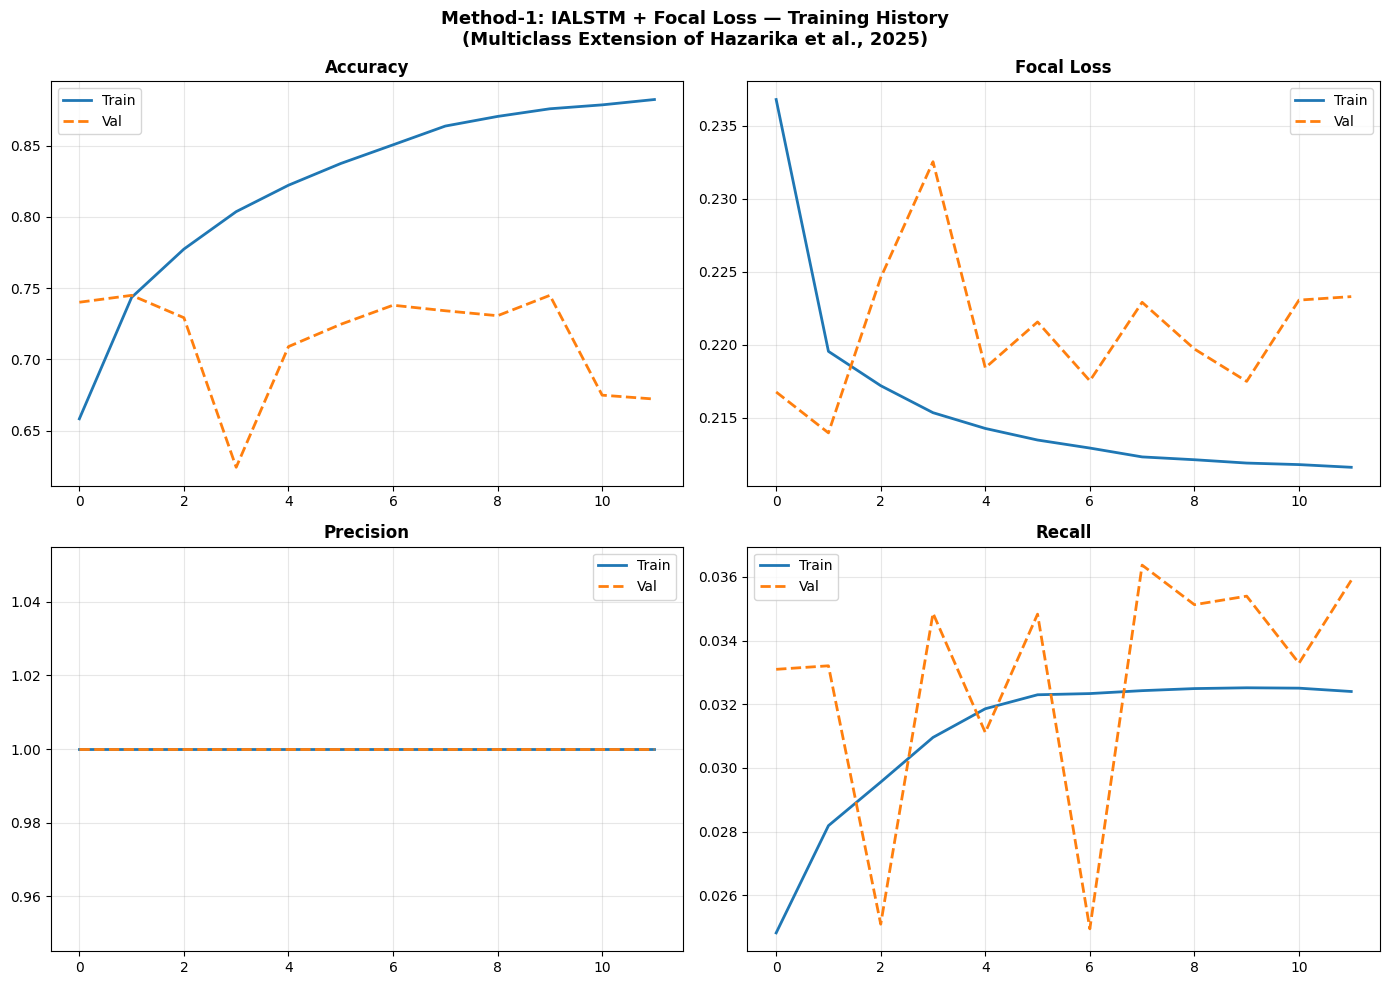

✓ IALSTM training history saved


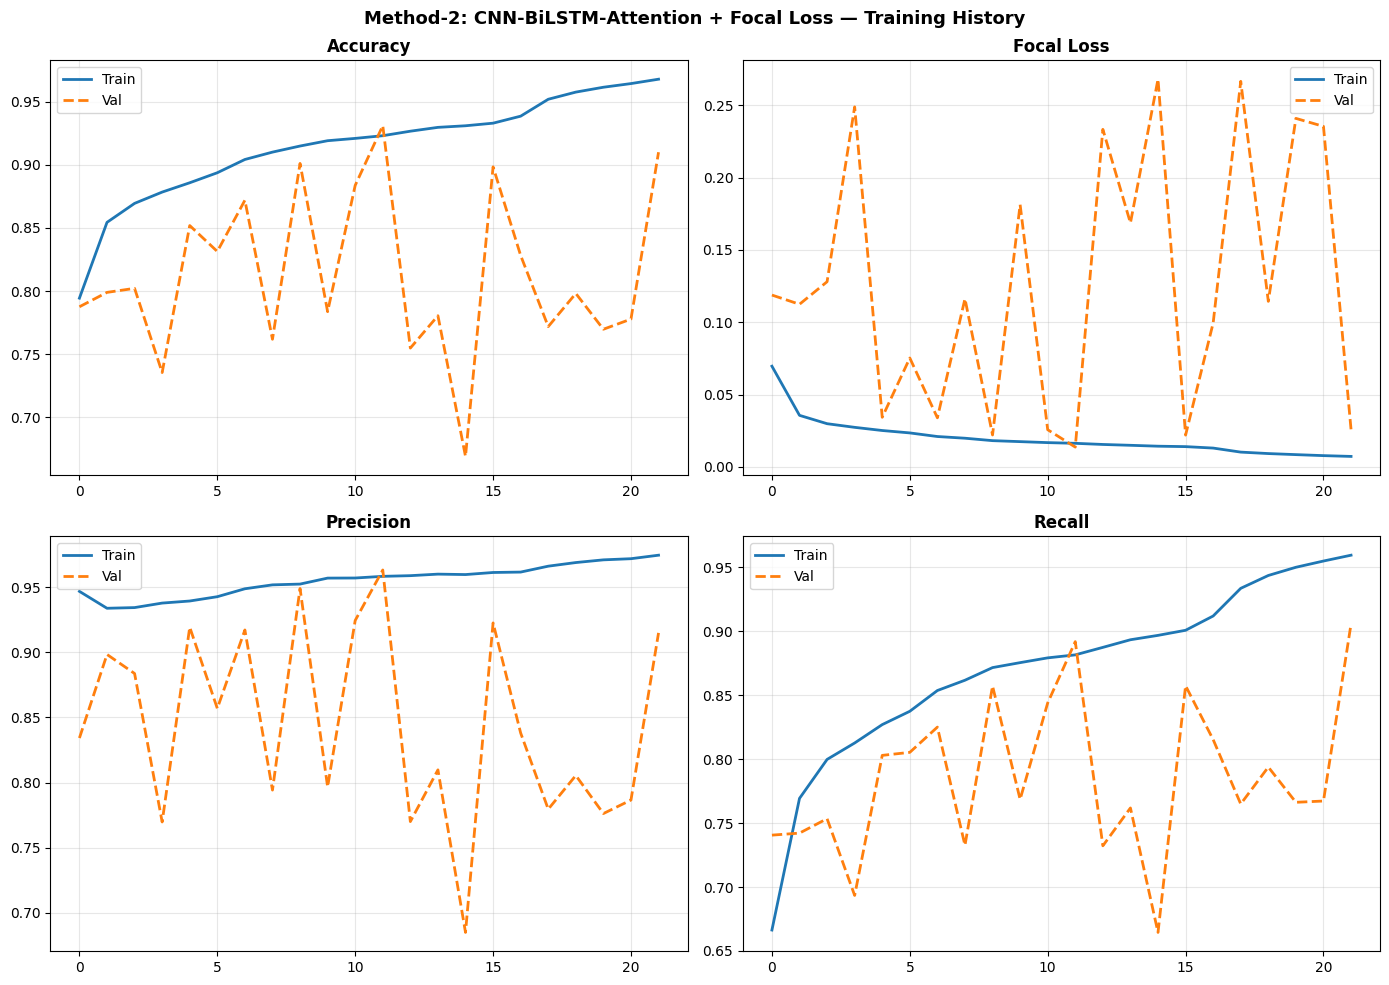

✓ CNN-BiLSTM training history saved


In [15]:
# ============================================================
# CELL 14: PLOTS — Training History
# ============================================================

# Method-1 IALSTM Training History
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Method-1: IALSTM + Focal Loss — Training History\n'
             '(Multiclass Extension of Hazarika et al., 2025)',
             fontsize=13, fontweight='bold')
for ax, (key, title) in zip(axes.flatten(), [
    ('accuracy','Accuracy'), ('loss','Focal Loss'),
    ('precision','Precision'), ('recall','Recall')
]):
    if key in history_m1.history:
        ax.plot(history_m1.history[key], label='Train', linewidth=2)
        ax.plot(history_m1.history.get(f'val_{key}', []),
                label='Val', linewidth=2, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/ialstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show(); print('✓ IALSTM training history saved')

# Method-2 CNN-BiLSTM Training History
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Method-2: CNN-BiLSTM-Attention + Focal Loss — Training History',
             fontsize=13, fontweight='bold')
for ax, (key, title) in zip(axes.flatten(), [
    ('accuracy','Accuracy'), ('loss','Focal Loss'),
    ('precision','Precision'), ('recall','Recall')
]):
    if key in history_m2.history:
        ax.plot(history_m2.history[key], label='Train', linewidth=2)
        ax.plot(history_m2.history.get(f'val_{key}', []),
                label='Val', linewidth=2, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/cnn_bilstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show(); print('✓ CNN-BiLSTM training history saved')

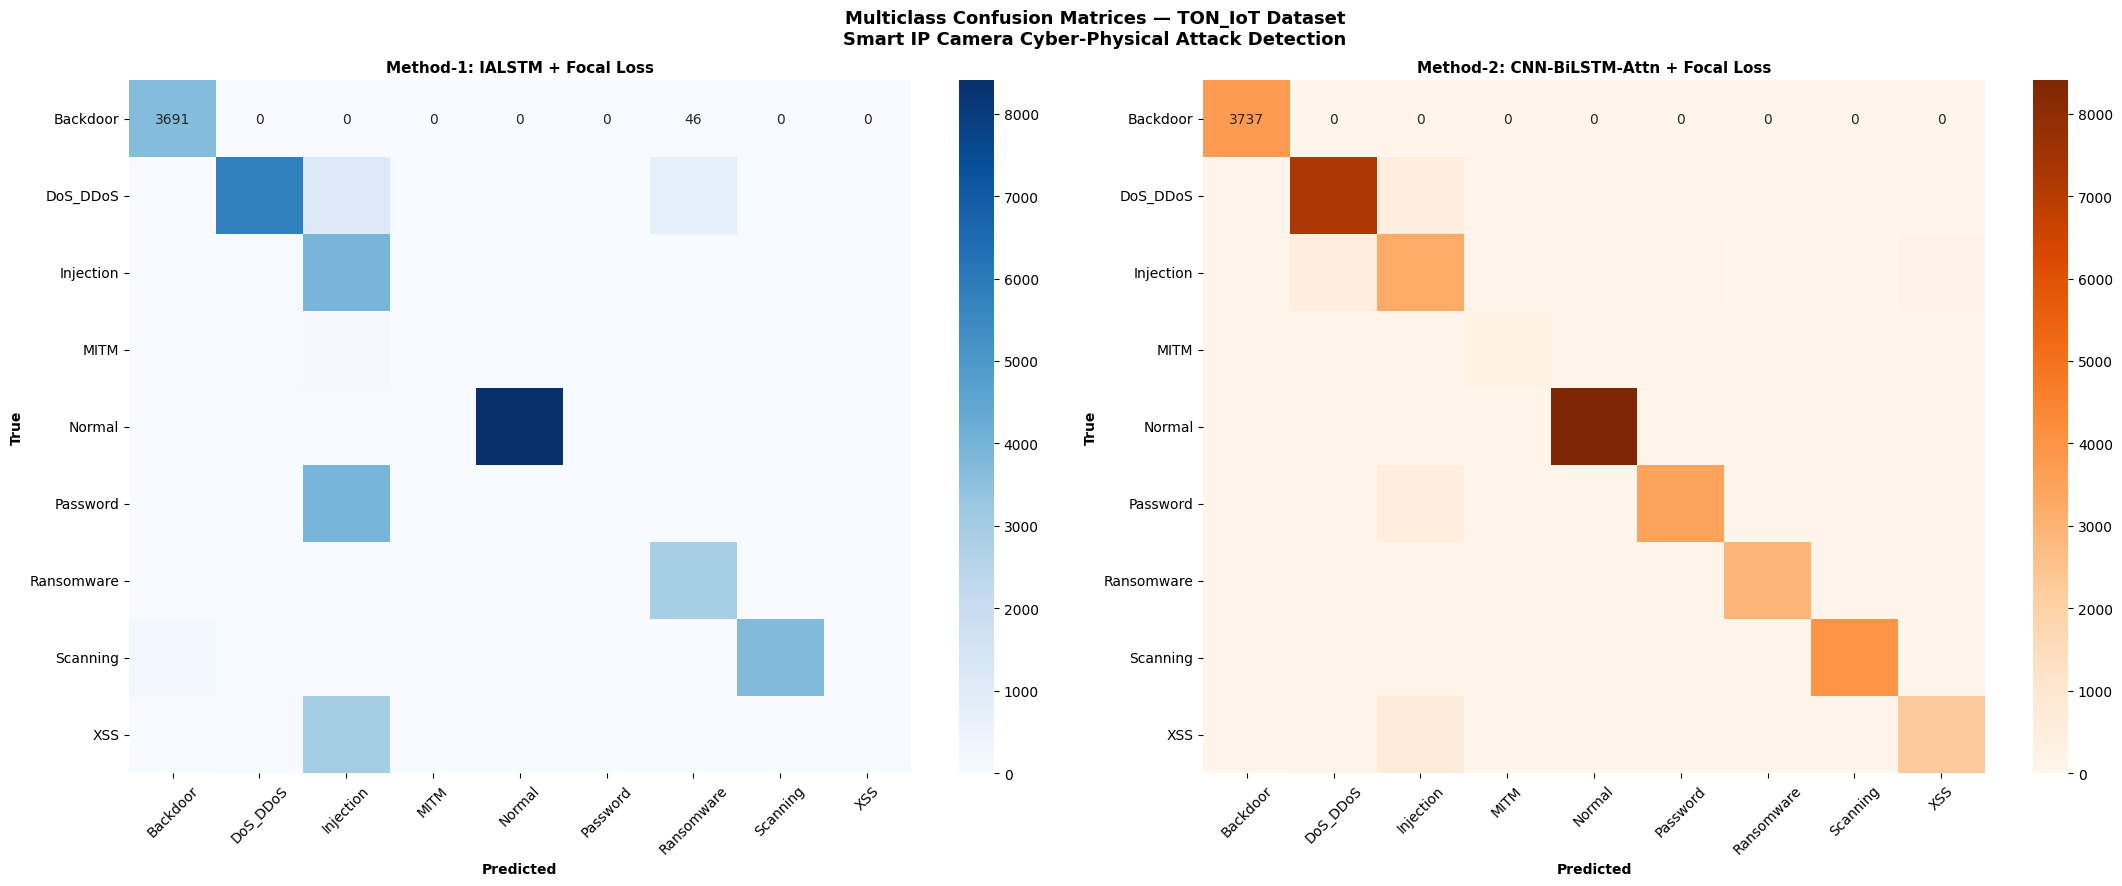

✓ Confusion matrices saved


In [16]:
# ============================================================
# CELL 15: PLOTS — Confusion Matrices (side by side)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('Multiclass Confusion Matrices — TON_IoT Dataset\n'
             'Smart IP Camera Cyber-Physical Attack Detection',
             fontsize=13, fontweight='bold')

for ax, y_pred, title, cmap in zip(
    axes,
    [y_pred_m1, y_pred_m2],
    ['Method-1: IALSTM + Focal Loss', 'Method-2: CNN-BiLSTM-Attn + Focal Loss'],
    ['Blues', 'Oranges']
):
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('True', fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plots/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show(); print('✓ Confusion matrices saved')

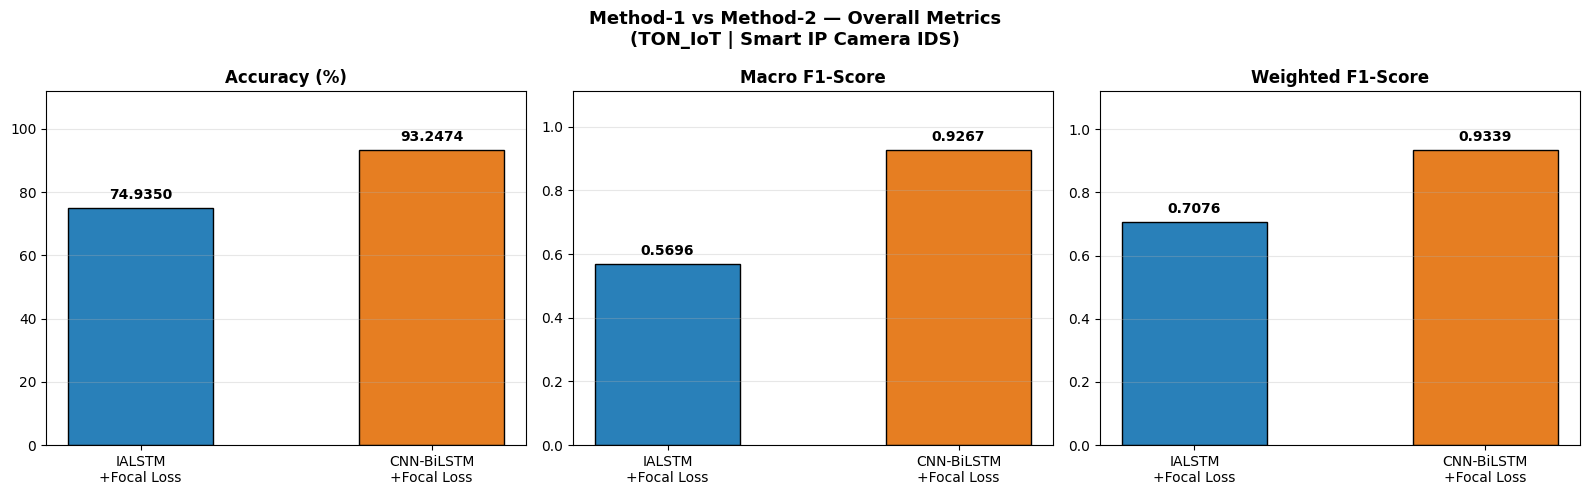

✓ Overall comparison saved


In [17]:
# ============================================================
# CELL 16: PLOTS — Overall Metric Comparison
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Method-1 vs Method-2 — Overall Metrics\n(TON_IoT | Smart IP Camera IDS)',
             fontsize=13, fontweight='bold')

methods = ['IALSTM\n+Focal Loss', 'CNN-BiLSTM\n+Focal Loss']
colors  = ['#2980b9', '#e67e22']
for ax, (vals, title) in zip(axes, [
    ([m1_acc*100, m2_acc*100],  'Accuracy (%)'),
    ([m1_mf1,    m2_mf1],      'Macro F1-Score'),
    ([m1_wf1,    m2_wf1],      'Weighted F1-Score')
]):
    bars = ax.bar(methods, vals, color=colors, width=0.5, edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+max(vals)*0.02,
                f'{v:.4f}', ha='center', va='bottom', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/overall_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); print('✓ Overall comparison saved')

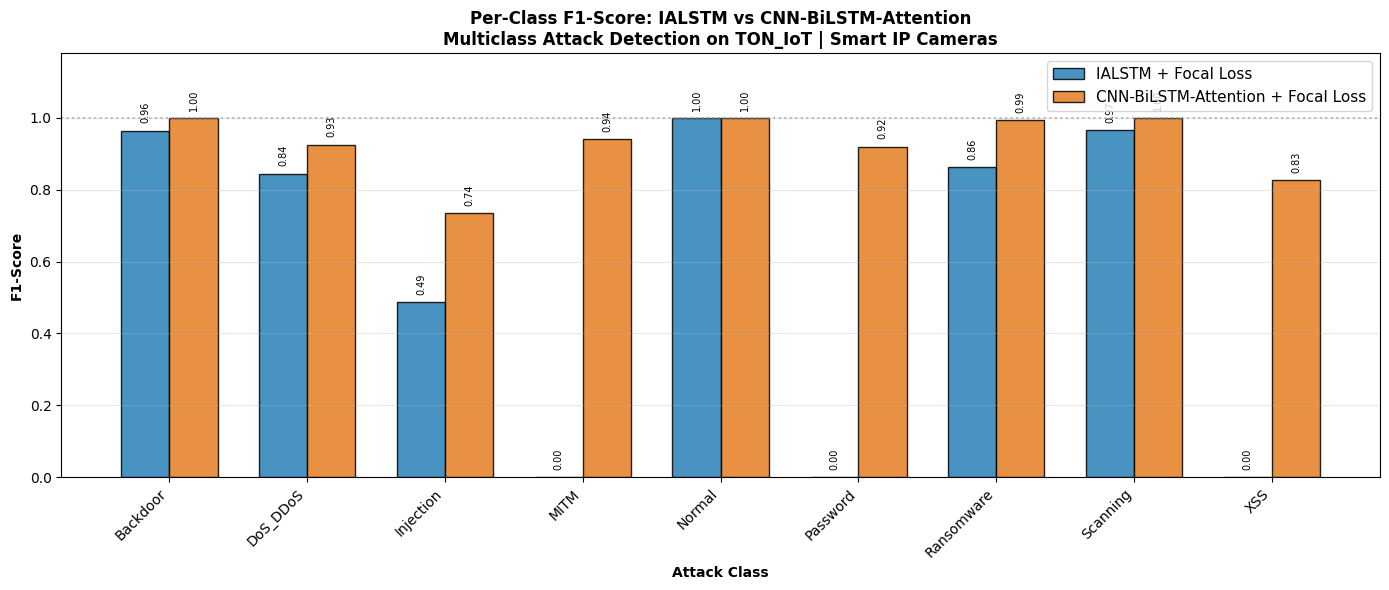

✓ Per-class F1 comparison saved


In [18]:
# ============================================================
# CELL 17: PLOTS — Per-Class F1 Comparison
# ============================================================
x, w = np.arange(NUM_CLASSES), 0.35
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x-w/2, m1_pcf1, w, label='IALSTM + Focal Loss',
       color='#2980b9', alpha=0.85, edgecolor='black')
ax.bar(x+w/2, m2_pcf1, w, label='CNN-BiLSTM-Attention + Focal Loss',
       color='#e67e22', alpha=0.85, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_xlabel('Attack Class', fontweight='bold')
ax.set_ylabel('F1-Score', fontweight='bold')
ax.set_title(
    'Per-Class F1-Score: IALSTM vs CNN-BiLSTM-Attention\n'
    'Multiclass Attack Detection on TON_IoT | Smart IP Cameras',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.18)
ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)
# Annotate bars
for i in range(NUM_CLASSES):
    ax.text(i-w/2, m1_pcf1[i]+0.02, f'{m1_pcf1[i]:.2f}',
            ha='center', va='bottom', fontsize=7, rotation=90)
    ax.text(i+w/2, m2_pcf1[i]+0.02, f'{m2_pcf1[i]:.2f}',
            ha='center', va='bottom', fontsize=7, rotation=90)
plt.tight_layout()
plt.savefig('plots/per_class_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); print('✓ Per-class F1 comparison saved')

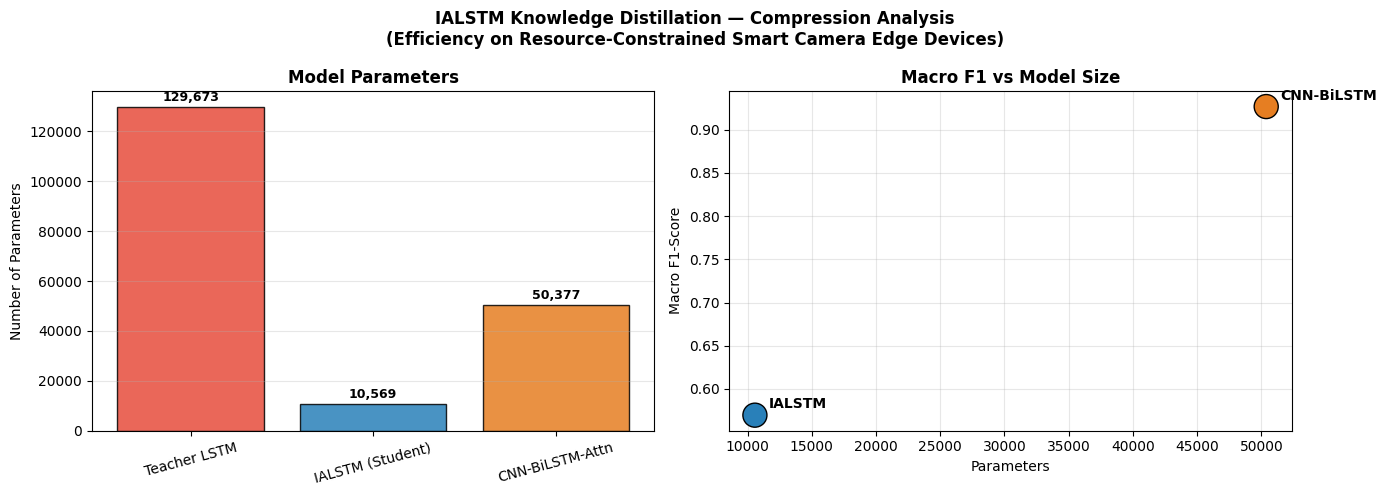

✓ Model compression analysis saved


In [19]:
# ============================================================
# CELL 18: PLOTS — Model Size Comparison (IALSTM contribution)
# Shows compression benefit of IALSTM vs Teacher
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('IALSTM Knowledge Distillation — Compression Analysis\n'
             '(Efficiency on Resource-Constrained Smart Camera Edge Devices)',
             fontsize=12, fontweight='bold')

models_compared = ['Teacher LSTM', 'IALSTM (Student)', 'CNN-BiLSTM-Attn']
param_counts    = [
    teacher.count_params(),
    ialstm.count_params(),
    model_m2.count_params()
]
colors_bar = ['#e74c3c', '#2980b9', '#e67e22']

# Parameter count
axes[0].bar(models_compared, param_counts, color=colors_bar,
            edgecolor='black', alpha=0.85)
axes[0].set_title('Model Parameters', fontweight='bold')
axes[0].set_ylabel('Number of Parameters')
for i, v in enumerate(param_counts):
    axes[0].text(i, v+max(param_counts)*0.01,
                 f'{v:,}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=15)

# Macro F1 vs parameter count scatter
model_mf1s = [None, m1_mf1, m2_mf1]  # Teacher not evaluated separately
axes[1].scatter(
    [param_counts[1], param_counts[2]],
    [m1_mf1, m2_mf1],
    c=['#2980b9', '#e67e22'], s=300, zorder=5, edgecolors='black'
)
for i, (p, f, n) in enumerate(zip(
    [param_counts[1], param_counts[2]],
    [m1_mf1, m2_mf1],
    ['IALSTM', 'CNN-BiLSTM']
)):
    axes[1].annotate(n, (p, f), textcoords='offset points',
                     xytext=(10, 5), fontweight='bold', fontsize=10)
axes[1].set_title('Macro F1 vs Model Size', fontweight='bold')
axes[1].set_xlabel('Parameters')
axes[1].set_ylabel('Macro F1-Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/model_compression_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Model compression analysis saved')

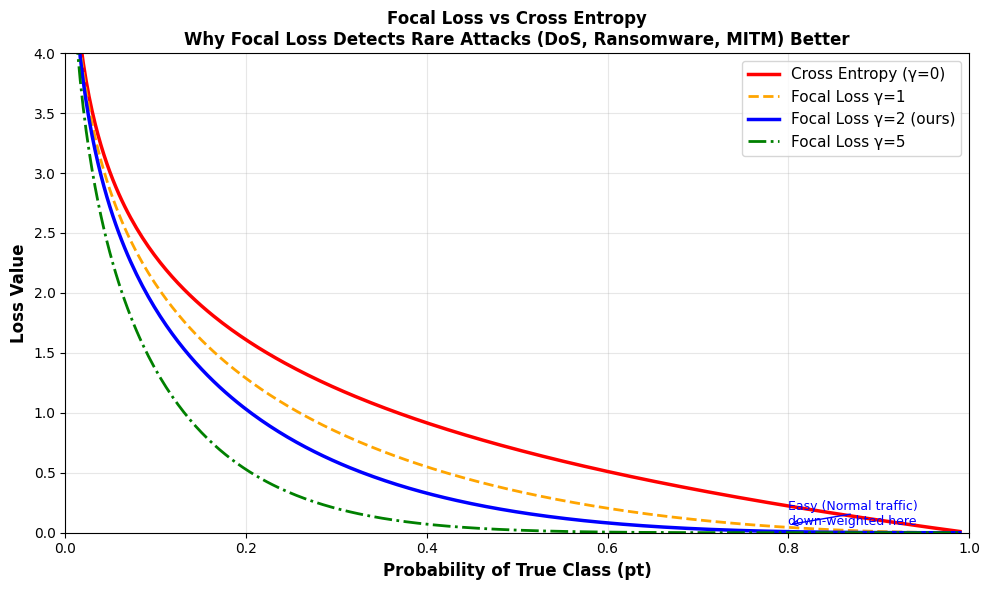

✓ Focal loss explanation plot saved
  This plot explains the motivation in your IEEE paper!


In [20]:
# ============================================================
# CELL 19: FOCAL LOSS vs CROSSENTROPY COMPARISON PLOT
# Shows WHY focal loss is better for imbalanced classes
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

pt = np.linspace(0.01, 0.99, 300)
ce = -np.log(pt)
fl_g1 = -(1-pt)**1.0 * np.log(pt)
fl_g2 = -(1-pt)**2.0 * np.log(pt)
fl_g5 = -(1-pt)**5.0 * np.log(pt)

ax.plot(pt, ce,    label='Cross Entropy (γ=0)', linewidth=2.5, color='red')
ax.plot(pt, fl_g1, label='Focal Loss γ=1',      linewidth=2,   color='orange', linestyle='--')
ax.plot(pt, fl_g2, label='Focal Loss γ=2 (ours)',linewidth=2.5, color='blue')
ax.plot(pt, fl_g5, label='Focal Loss γ=5',      linewidth=2,   color='green',  linestyle='-.')

ax.set_xlim(0, 1); ax.set_ylim(0, 4)
ax.set_xlabel('Probability of True Class (pt)', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss Value', fontsize=12, fontweight='bold')
ax.set_title(
    'Focal Loss vs Cross Entropy\n'
    'Why Focal Loss Detects Rare Attacks (DoS, Ransomware, MITM) Better',
    fontsize=12, fontweight='bold'
)
ax.annotate('Easy (Normal traffic)\ndown-weighted here',
            xy=(0.8, -np.log(0.8)*0.3), fontsize=9, color='blue',
            arrowprops=dict(arrowstyle='->', color='blue'))
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/focal_loss_explanation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Focal loss explanation plot saved')
print('  This plot explains the motivation in your IEEE paper!')

In [21]:
# ============================================================
# CELL 20: SAVE ALL RESULTS
# ============================================================
results = {
    'timestamp'  : TIMESTAMP,
    'dataset'    : 'TON_IoT (Network data)',
    'base_paper' : 'Hazarika et al., IEEE Trans. ICPS, 2025',
    'our_novelty': (
        'First multiclass (10-class) extension of IALSTM for smart IP cameras. '
        'Applied Focal Loss to handle class imbalance in TON_IoT. '
        'Extended from binary (Normal/Attack) to 9 attack type classification.'
    ),
    'num_classes': NUM_CLASSES,
    'classes'    : CLASS_NAMES,
    'method1': {
        'name'         : 'IALSTM + Focal Loss (Multiclass)',
        'description'  : 'Knowledge Distillation LSTM with Focal Loss — extended from base paper binary to multiclass',
        'teacher_params': teacher.count_params(),
        'student_params': ialstm.count_params(),
        'compression'  : f'{teacher.count_params()/ialstm.count_params():.1f}x',
        'accuracy'     : round(float(m1_acc), 6),
        'macro_f1'     : round(float(m1_mf1),  6),
        'weighted_f1'  : round(float(m1_wf1),  6),
        'per_class_f1' : {c: round(float(f), 4)
                          for c, f in zip(CLASS_NAMES, m1_pcf1)},
    },
    'method2': {
        'name'        : 'CNN-BiLSTM-Attention + Focal Loss (Multiclass)',
        'description' : 'Hybrid CNN + Bidirectional LSTM + Multi-Head Attention with Focal Loss',
        'params'      : model_m2.count_params(),
        'accuracy'    : round(float(m2_acc), 6),
        'macro_f1'    : round(float(m2_mf1),  6),
        'weighted_f1' : round(float(m2_wf1),  6),
        'per_class_f1': {c: round(float(f), 4)
                         for c, f in zip(CLASS_NAMES, m2_pcf1)},
    }
}

with open(f'results/final_results_{TIMESTAMP}.json', 'w') as f:
    json.dump(results, f, indent=4)

print('='*60)
print('ALL DONE! 🎉')
print('='*60)
print(f'\n📊 Final Comparison:')
print(f'  {"Metric":<22} {"IALSTM+FL":>16} {"CNN-BiLSTM+FL":>16}')
print(f'  {"-"*56}')
print(f'  {"Accuracy":<22} {m1_acc*100:>15.2f}% {m2_acc*100:>15.2f}%')
print(f'  {"Macro F1":<22} {m1_mf1:>16.4f} {m2_mf1:>16.4f}')
print(f'\n  Teacher params : {teacher.count_params():,}')
print(f'  IALSTM params  : {ialstm.count_params():,} ({teacher.count_params()/ialstm.count_params():.1f}x smaller)')
print(f'\n📁 Plots saved:')
for p in [
    'ialstm_training_history', 'cnn_bilstm_training_history',
    'confusion_matrices', 'overall_comparison',
    'per_class_f1_comparison', 'model_compression_analysis',
    'focal_loss_explanation'
]:
    print(f'  plots/{p}.png')
print(f'\n  results/final_results_{TIMESTAMP}.json')
print(f'  models/ialstm_multiclass_{TIMESTAMP}.h5')
print(f'  models/cnn_bilstm_multiclass_{TIMESTAMP}.h5')
print('\n✅ Ready for IEEE report!')
print('='*60)

ALL DONE! 🎉

📊 Final Comparison:
  Metric                        IALSTM+FL    CNN-BiLSTM+FL
  --------------------------------------------------------
  Accuracy                         74.94%           93.25%
  Macro F1                         0.5696           0.9267

  Teacher params : 129,673
  IALSTM params  : 10,569 (12.3x smaller)

📁 Plots saved:
  plots/ialstm_training_history.png
  plots/cnn_bilstm_training_history.png
  plots/confusion_matrices.png
  plots/overall_comparison.png
  plots/per_class_f1_comparison.png
  plots/model_compression_analysis.png
  plots/focal_loss_explanation.png

  results/final_results_20260417_200142.json
  models/ialstm_multiclass_20260417_200142.h5
  models/cnn_bilstm_multiclass_20260417_200142.h5

✅ Ready for IEEE report!


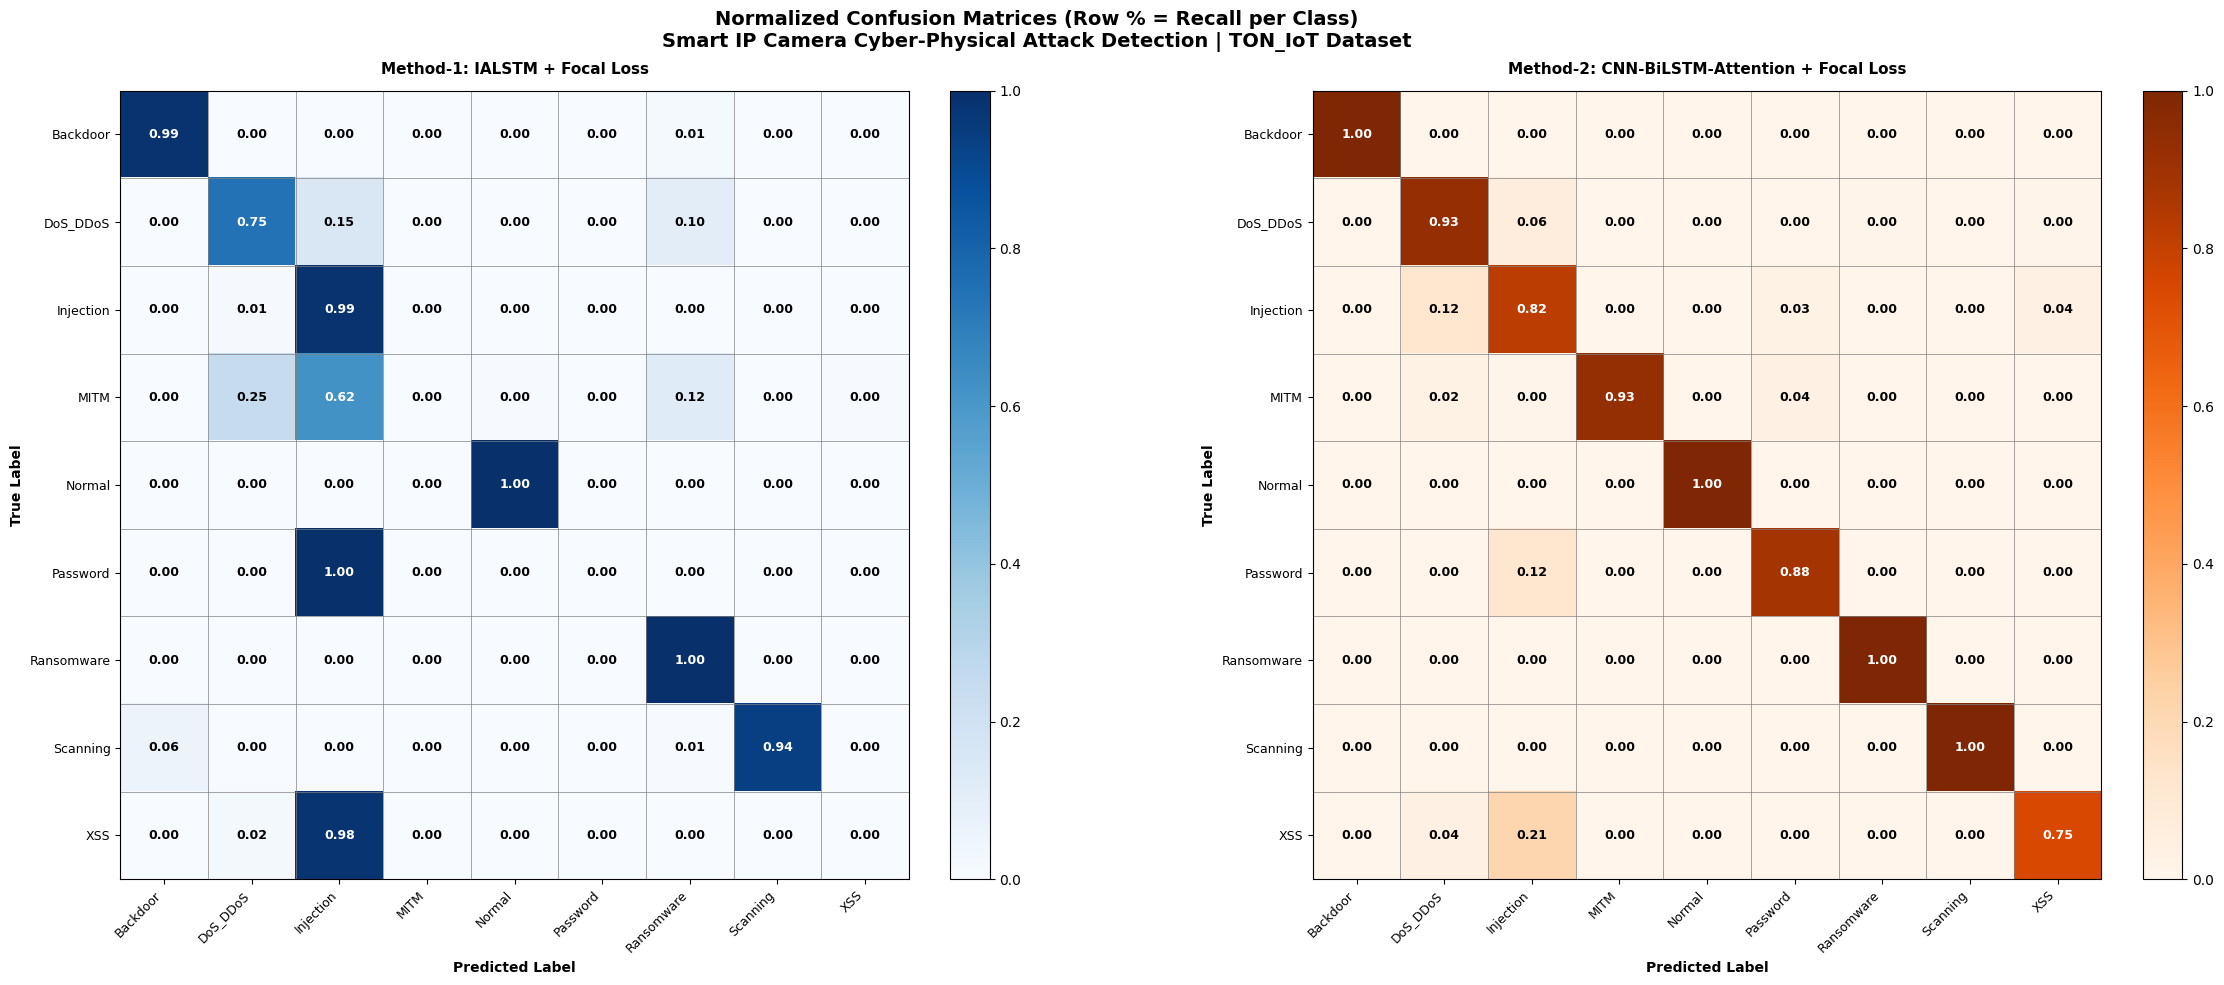

✓ Normalized confusion matrix (FIXED) saved


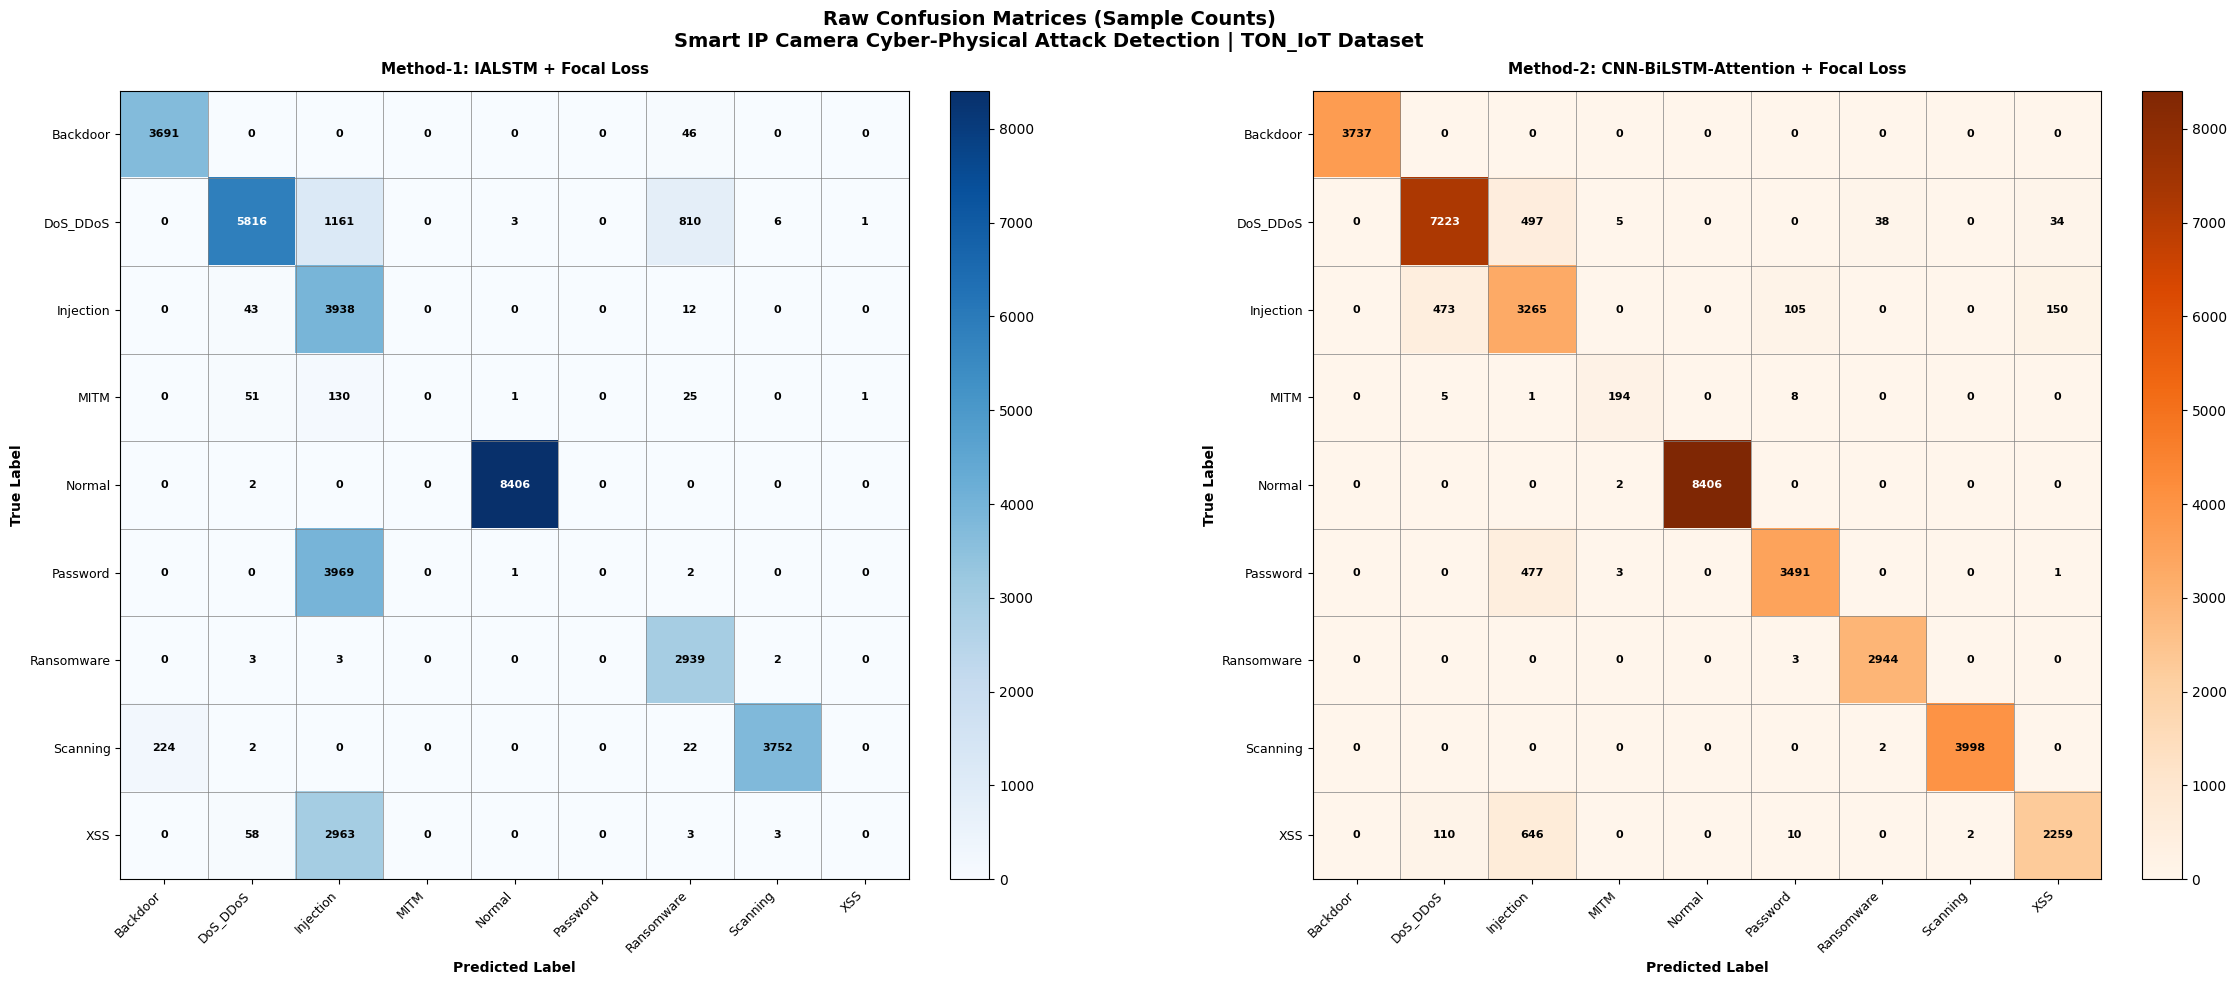

✓ Raw confusion matrix (FIXED) saved

PER-CLASS RECALL (%) — from Confusion Matrix
Class                 IALSTM+FL    CNN-BiLSTM+FL
------------------------------------------------
Backdoor                  98.8%           100.0%
DoS_DDoS                  74.6%            92.6%
Injection                 98.6%            81.8%
MITM                       0.0%            93.3%
Normal                   100.0%           100.0%
Password                   0.0%            87.9%
Ransomware                99.7%            99.9%
Scanning                  93.8%            99.9%
XSS                        0.0%            74.6%


In [23]:
# ============================================================
# FIXED CONFUSION MATRIX — Numbers visible on ALL cells
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

y_pred_m1 = np.argmax(ialstm.predict(X_te, verbose=0), axis=1)
y_pred_m2 = np.argmax(model_m2.predict(X_te, verbose=0), axis=1)

def plot_confusion_matrix_fixed(ax, y_true, y_pred, class_names, title, cmap_name):
    cm = confusion_matrix(y_true, y_pred)
    # Normalize by row
    cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-9)

    cmap = plt.get_cmap(cmap_name)
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Tick labels
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)

    # Annotate every cell with BLACK or WHITE text depending on background
    thresh = 0.5  # switch text color at this value
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            val = cm_norm[i, j]
            # Dark background → white text; Light background → black text
            text_color = 'white' if val > thresh else 'black'
            ax.text(
                j, i,
                f'{val:.2f}',
                ha='center', va='center',
                color=text_color,
                fontsize=9,
                fontweight='bold'
            )

    ax.set_title(title, fontweight='bold', fontsize=11, pad=12)
    ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=10)
    ax.set_ylabel('True Label', fontweight='bold', fontsize=10)

    # Draw grid lines between cells
    ax.set_xticks(np.arange(len(class_names)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(class_names)) - 0.5, minor=True)
    ax.grid(which='minor', color='gray', linewidth=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)

# -------------------------------------------------------
# Plot 1: Normalized (Row %) — USE THIS FOR IEEE PAPER
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(24, 10))
fig.suptitle(
    'Normalized Confusion Matrices (Row % = Recall per Class)\n'
    'Smart IP Camera Cyber-Physical Attack Detection | TON_IoT Dataset',
    fontsize=14, fontweight='bold'
)

plot_confusion_matrix_fixed(
    axes[0], y_te, y_pred_m1, CLASS_NAMES,
    'Method-1: IALSTM + Focal Loss', 'Blues'
)
plot_confusion_matrix_fixed(
    axes[1], y_te, y_pred_m2, CLASS_NAMES,
    'Method-2: CNN-BiLSTM-Attention + Focal Loss', 'Oranges'
)

plt.tight_layout()
plt.savefig('plots/confusion_matrix_normalized_FIXED.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Normalized confusion matrix (FIXED) saved')

# -------------------------------------------------------
# Plot 2: Raw Counts
# -------------------------------------------------------
def plot_cm_raw(ax, y_true, y_pred, class_names, title, cmap_name):
    cm = confusion_matrix(y_true, y_pred)
    max_val = cm.max()
    cmap = plt.get_cmap(cmap_name)
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)
    thresh = max_val / 2
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            val = cm[i, j]
            text_color = 'white' if val > thresh else 'black'
            ax.text(j, i, str(val),
                    ha='center', va='center',
                    color=text_color, fontsize=8, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=11, pad=12)
    ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=10)
    ax.set_ylabel('True Label', fontweight='bold', fontsize=10)
    ax.set_xticks(np.arange(len(class_names)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(class_names)) - 0.5, minor=True)
    ax.grid(which='minor', color='gray', linewidth=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
fig.suptitle(
    'Raw Confusion Matrices (Sample Counts)\n'
    'Smart IP Camera Cyber-Physical Attack Detection | TON_IoT Dataset',
    fontsize=14, fontweight='bold'
)
plot_cm_raw(axes[0], y_te, y_pred_m1, CLASS_NAMES,
            'Method-1: IALSTM + Focal Loss', 'Blues')
plot_cm_raw(axes[1], y_te, y_pred_m2, CLASS_NAMES,
            'Method-2: CNN-BiLSTM-Attention + Focal Loss', 'Oranges')
plt.tight_layout()
plt.savefig('plots/confusion_matrix_raw_FIXED.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Raw confusion matrix (FIXED) saved')

# -------------------------------------------------------
# Print table
# -------------------------------------------------------
print('\n' + '='*55)
print('PER-CLASS RECALL (%) — from Confusion Matrix')
print('='*55)
print(f'{"Class":<16} {"IALSTM+FL":>14} {"CNN-BiLSTM+FL":>16}')
print('-'*48)
cm1 = confusion_matrix(y_te, y_pred_m1)
cm2 = confusion_matrix(y_te, y_pred_m2)
for i, cls in enumerate(CLASS_NAMES):
    r1 = cm1[i, i] / (cm1[i].sum() + 1e-9) * 100
    r2 = cm2[i, i] / (cm2[i].sum() + 1e-9) * 100
    print(f'{cls:<16} {r1:>13.1f}% {r2:>15.1f}%')